In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.stattools import adfuller, kpss

In [10]:
# Show all rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_rows', 1000)

DRCC =  Credit Card Delinquency rate (all commercial banks)
COR = Credit card charge-off rate
TERM = Terms on Credit Card plans

In [11]:
corc_df = pd.read_csv('../data/CORCCACBS.csv')
drcc_df = pd.read_csv('../data/DRCCLACBS.csv')
term_df = pd.read_csv('../data/TERMCBCCALLNS.csv')

In [ ]:
print(corc_df.head(15))
print(drcc_df[drcc_df['date']>'1994'])
print(term_df.head(15))

Organize our data - it currently has multiple entries for each date + has a hours/minutes/second. I'll make a function to make this more streamlined

In [12]:

def fix_df(df):

    a=df.groupby(df['date'])['value'].mean().round(2)
    
    b = pd.to_datetime(df['date'].unique())

    df = pd.DataFrame({
        'date':b,
        'value':a.values
    })

    df = df.set_index('date')

    return df



In [13]:
drcc_df = fix_df(drcc_df)
corc_df = fix_df(corc_df)
term_df = fix_df(term_df)
term_df = term_df.dropna()

In [ ]:
print(drcc_df.head(1))
print(corc_df.head(1))
print(term_df.head(1))
print(len(drcc_df),len(corc_df),len(term_df))

lets plot them (full dataset for now)

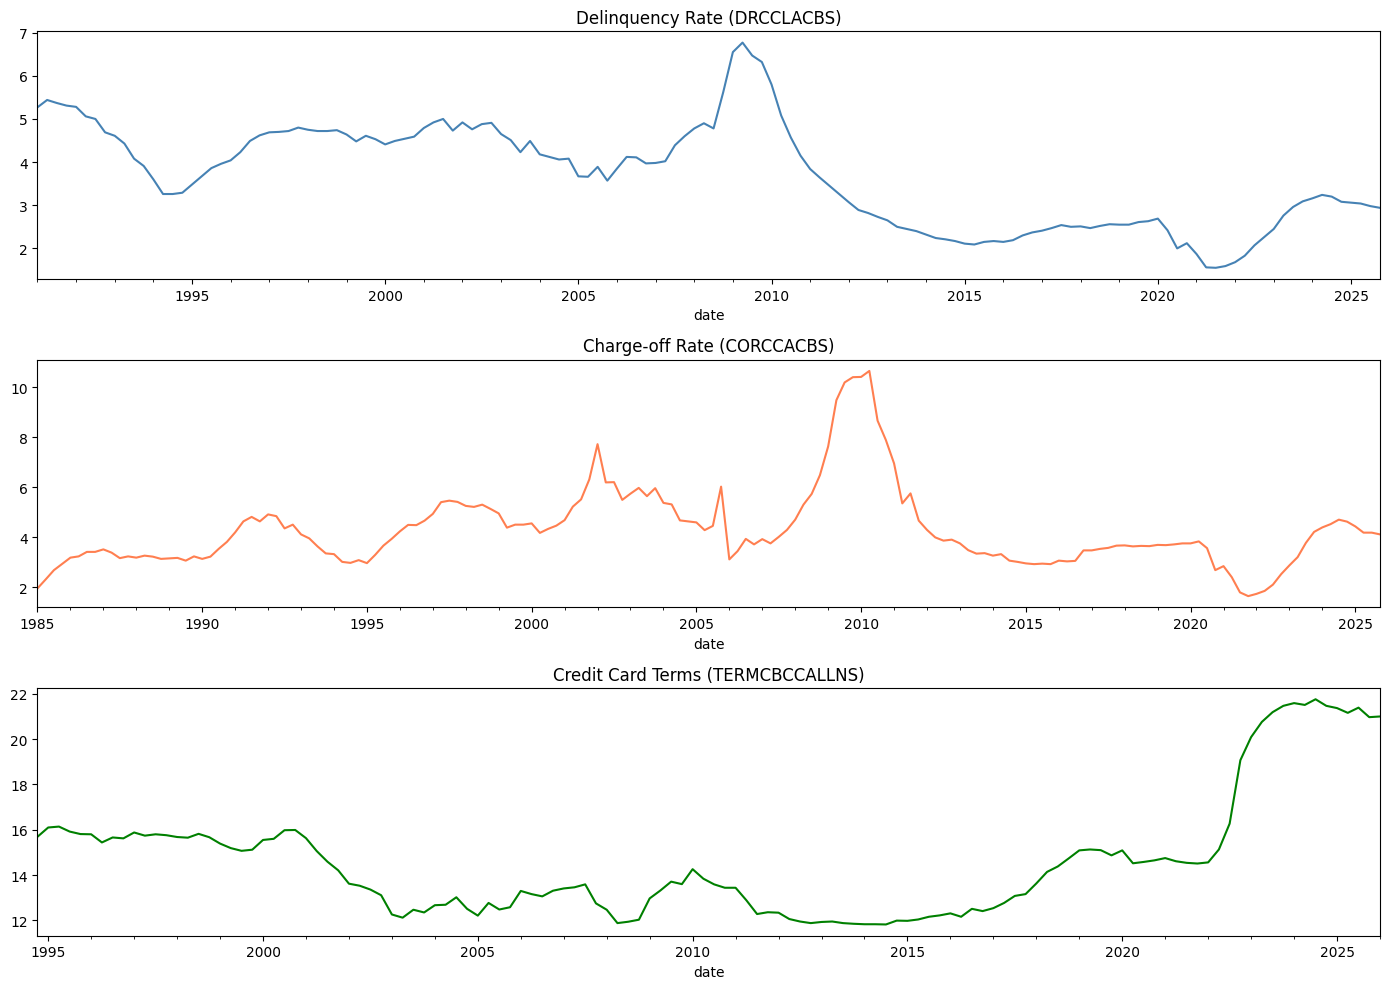

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

drcc_df['value'].plot(ax=axes[0], title='Delinquency Rate (DRCCLACBS)', color='steelblue')
corc_df['value'].plot(ax=axes[1], title='Charge-off Rate (CORCCACBS)', color='coral')
term_df['value'].plot(ax=axes[2], title='Credit Card Terms (TERMCBCCALLNS)', color='green')

plt.tight_layout()
plt.show()

We have a time mismatch clearly, how should I split?
A couple of ideas:

- Align our data to yearly data, that way we'll have more aligned data points but probably not the best idea will be mising out on (4!!) predictions per year, since the data we're looking for, the delinquency rate, is calculated quarterly.

- try to match where we can? maybe align closes data to that data point ??

- let Pandas try to match the timelines as best it can

Let pandas merge

In [ ]:
df_multi = pd.concat([drcc_df,corc_df,term_df], axis =1 , join='outer')

In [ ]:
# we chose 1995, since thats the latest date that they all have data

df_multi = df_multi.loc["1995":]
print(len(df_multi),df_multi.head(10))


df_multinfiltered = df_multi.asfreq('QS').dropna()

print(len(df_multinfiltered))


#this had a much higher count since term had data starting at a much earlier date than the other two.

without term this time:
also Changing the name of Column from value to distinct name 

In [6]:
drcc_df.rename(columns={'value': 'delinquency'}, inplace=True)
corc_df.rename(columns={'value': 'charge_off'}, inplace=True)

In [7]:
df_multi1 = pd.concat([drcc_df,corc_df], axis =1 , join='outer')
print(len(df_multi1),df_multi1.head(10))


df_multi1=df_multi1.asfreq('QS').dropna()
print(len(df_multi1),df_multi1.head(10))

164             delinquency  charge_off
date                               
1985-01-01          NaN        1.95
1985-04-01          NaN        2.31
1985-07-01          NaN        2.68
1985-10-01          NaN        2.93
1986-01-01          NaN        3.18
1986-04-01          NaN        3.23
1986-07-01          NaN        3.41
1986-10-01          NaN        3.41
1987-01-01          NaN        3.51
1987-04-01          NaN        3.38
140             delinquency  charge_off
date                               
1991-01-01         5.27        4.19
1991-04-01         5.44        4.63
1991-07-01         5.37        4.81
1991-10-01         5.31        4.63
1992-01-01         5.28        4.91
1992-04-01         5.06        4.84
1992-07-01         5.00        4.35
1992-10-01         4.69        4.50
1993-01-01         4.61        4.11
1993-04-01         4.43        3.95


C:\Users\Marwa\AppData\Local\Temp\ipykernel_21300\345477396.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_multi1 = pd.concat([drcc_df,corc_df], axis =1 , join='outer')


## TERMCBCCALLNS — dropped

- Excluded due to time cycle mismatch -> quarterly cycle (QS-NOV vs QS-JAN) 
- data loss on merge (249 to 0 observations) after dropping Null



#### Next, we'll split into train val test

also introduce a feature engineered variable, 'anamoly flag'

In [17]:
def traintestsplit(df):
    train = df.loc[:'2015']
    val = df.loc['2016':'2019']
    test = df.loc['2020':]

    return train,val ,test

# this only includes delinquency rates as well as charge off rates. Now we'll split
train_mv, val_mv, test_mv = traintestsplit(df_multi1)

train_mv_withFE = train_mv.copy()

train_mv_withFE['anamoly_flag'] = ((train_mv_withFE['charge_off'] > 5) | # rates are too high
                                   (train_mv_withFE['charge_off'] < 2.0)).astype(int) # rates are artificially low (ex. COVID)




In [ ]:
print(len(train_mv_withFE[train_mv_withFE['anamoly_flag']==1])) # 35 points in time where we had 'anamoly' rates!

35


PLOT!!! Lets plot how when times were roughhhh!?